In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install "pandas<2.2.0" wfdb -U

  Using cached wfdb-4.3.0-py3-none-any.whl.metadata (3.8 kB)
INFO: pip is looking at multiple versions of wfdb to determine which version is compatible with other requirements. This could take a while.
  Using cached wfdb-4.2.0-py3-none-any.whl.metadata (3.7 kB)


Device: cuda

[normal-sinus-rhythm-rr-interval-database-1.0.0] Found 54 records.
Loaded 54 RR records.
RR length: min=76849 mean=107358.1 max=136536
RR scale (s): 1%/50%/99% = 0.4531/0.7578/1.2031
HR sanity (BPM): min=20.1 mean=81.1 max=295.4

[mit-bih-normal-sinus-rhythm-database-1.0.0] Found 18 records.
Loaded 18 RR records.
RR length: min=81830 mean=100121.4 max=117100
RR scale (s): 1%/50%/99% = 0.3281/0.7656/1.2031
HR sanity (BPM): min=23.3 mean=83.3 max=295.4

Built fixed samples:
  Train (nsr2db): 66696 samples
  Test  (MIT)   : 21081 samples

TRAINING
Train samples: 66696 | batch size: 32 | batches: 2085
RR clamp range (TRAIN 0.5%..99.5%): [0.4297, 1.0938] s


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 001 | D=0.1388 | G=222.1185 | MissMAE(z)=0.4424 | dRRloss(z)=0.4477
Epoch 002 | D=-0.2411 | G=212.1084 | MissMAE(z)=0.4225 | dRRloss(z)=0.4278
Epoch 003 | D=-0.2608 | G=205.5945 | MissMAE(z)=0.4095 | dRRloss(z)=0.4141
Epoch 004 | D=-0.2777 | G=198.4614 | MissMAE(z)=0.3953 | dRRloss(z)=0.3998
Epoch 005 | D=-0.3121 | G=195.9472 | MissMAE(z)=0.3903 | dRRloss(z)=0.3950
Epoch 006 | D=-0.3213 | G=192.0513 | MissMAE(z)=0.3848 | dRRloss(z)=0.3893
Epoch 007 | D=-0.3257 | G=193.1048 | MissMAE(z)=0.3834 | dRRloss(z)=0.3882
Epoch 008 | D=-0.3297 | G=193.3914 | MissMAE(z)=0.3791 | dRRloss(z)=0.3842
Epoch 009 | D=-0.3302 | G=194.3121 | MissMAE(z)=0.3767 | dRRloss(z)=0.3816
Epoch 010 | D=-0.3315 | G=195.7024 | MissMAE(z)=0.3764 | dRRloss(z)=0.3814
Epoch 011 | D=-0.3344 | G=195.1014 | MissMAE(z)=0.3739 | dRRloss(z)=0.3789
Epoch 012 | D=-0.3335 | G=195.3292 | MissMAE(z)=0.3726 | dRRloss(z)=0.3778
Epoch 013 | D=-0.3341 | G=194.4691 | MissMAE(z)=0.3717 | dRRloss(z)=0.3770
Epoch 014 | D=-0.3362 | G=

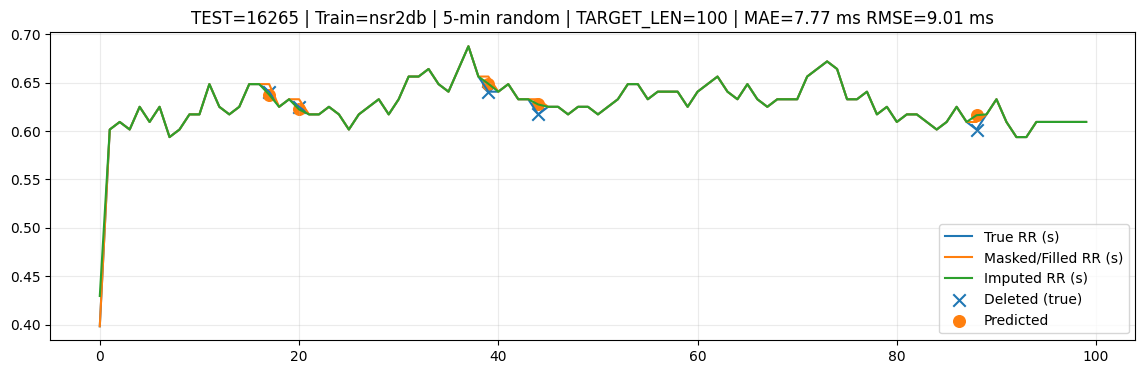

Eval on 10 test samples: MAE=0.013456 s | RMSE=0.020417 s
Saved: /kaggle/working/rr_imputer_TRAIN_nsr2db_TEST_mit_nsrdb_5min_RANDOM_wgangp.pt


In [2]:
# ============================================================
# KAGGLE FULL NOTEBOOK (ALL-IN-ONE) ✅
# TRAIN: Normal Sinus Rhythm RR-Interval DB (nsr2db)
#   normal-sinus-rhythm-rr-interval-database-1.0.0  (nsr001.ecg, nsr001.hea, ...)
# TEST : MIT-BIH Normal Sinus Rhythm DB (nsrdb)
#   mit-bih-normal-sinus-rhythm-database-1.0.0 (16265.atr, 16265.dat, 16265.hea, ...)
#
# TASK: RR interval imputation (SECONDS)
#   - 5-minute segments (300s)
#   - fixed-length (TARGET_LEN beats)
#   - RANDOM scattered missing only (K points)
#   - LSTM Generator (residual) + WGAN-GP Critic (CNN)
#   - Missing-only MAE + dRR physiology loss
#   - Debug prints + plot on a test sample
# ============================================================

import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import wfdb

# -------------------------
# CONFIG
# -------------------------
# ✅ TRAIN on RR-interval DB (nsr2db)
TRAIN_ROOT = "/kaggle/input/nsrrrid/normal-sinus-rhythm-rr-interval-database-1.0.0"

# ✅ TEST on MIT NSRDB (nsrdb)
TEST_ROOT  = "/kaggle/input/mit-bih-normal-sinus-rhythm-database/mit-bih-normal-sinus-rhythm-database-1.0.0"

SEG_S        = 60.0      # 1 minute
TARGET_LEN   = 100       # fixed-length beats
MIN_LEN_KEEP = 60        # minimum beats to keep

K_MISSING    = 5          # RANDOM scattered missing only
FILL_MODE    = "ffill"    # "mean" or "ffill"

BATCH_SIZE    = 32
EPOCHS        = 30
WARMUP_EPOCHS = 5
N_CRITIC      = 1

LR_G = 1e-4
LR_D = 1e-4

LAMBDA_MISS   = 500.0
LAMBDA_DRR    = 2.0
LAMBDA_SMOOTH = 0.0
GP_LAMBDA     = 10.0

SEED = 42

# -------------------------
# Reproducibility
# -------------------------
def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# Helpers: list records + detect annotation extension
# ============================================================
def list_records(dataset_root: str):
    rec_path = os.path.join(dataset_root, "RECORDS")
    if os.path.isfile(rec_path):
        with open(rec_path, "r") as f:
            return [ln.strip() for ln in f if ln.strip()]
    return sorted([fn.replace(".hea", "") for fn in os.listdir(dataset_root) if fn.endswith(".hea")])

def detect_ann_ext(dataset_root: str, rec: str, candidates=("atr","ecg","ann","qrs")):
    """Pick the first extension where rec.<ext> exists."""
    for ext in candidates:
        if os.path.isfile(os.path.join(dataset_root, f"{rec}.{ext}")):
            return ext
    return None

# ============================================================
# 1) LOAD RR FROM WFDB ANNOTATIONS
#    RR in seconds: diff(samples)/fs
# ============================================================
def load_rr_records_from_wfdb(dataset_root: str, ann_ext=None, verbose=True, ext_candidates=("atr","ecg","ann","qrs")):
    rr_dict, fs_dict = {}, {}
    recs = list_records(dataset_root)
    if verbose:
        print(f"\n[{os.path.basename(dataset_root)}] Found {len(recs)} records.")

    for rec in recs:
        try:
            rec_path = os.path.join(dataset_root, rec)
            header = wfdb.rdheader(rec_path)
            fs = float(header.fs) if header.fs is not None else None
            if fs is None:
                raise RuntimeError("Header fs is None")

            use_ext = ann_ext
            if use_ext is None:
                use_ext = detect_ann_ext(dataset_root, rec, candidates=ext_candidates)
                if use_ext is None:
                    raise RuntimeError("No annotation file found (tried: %s)" % (",".join(ext_candidates)))

            ann = wfdb.rdann(rec_path, use_ext)
            samples = np.asarray(ann.sample, dtype=np.int64)
            if samples.size < 2:
                raise RuntimeError("Not enough annotations")

            rr_s = (np.diff(samples) / fs).astype(np.float32)

            # cleaning
            rr_s = rr_s[np.isfinite(rr_s)]
            rr_s = rr_s[(rr_s > 0.2) & (rr_s < 3.0)]

            if rr_s.size < 1000:
                raise RuntimeError(f"Too few RR after cleaning: {rr_s.size}")

            rr_dict[rec] = rr_s
            fs_dict[rec] = fs

        except Exception as e:
            if verbose:
                print(f"Skip {rec}: {e}")

    if verbose:
        print(f"Loaded {len(rr_dict)} RR records.")
        if len(rr_dict) > 0:
            lens = [len(v) for v in rr_dict.values()]
            all_rr = np.concatenate(list(rr_dict.values())).astype(np.float64)
            p1, p50, p99 = np.percentile(all_rr, [1, 50, 99])
            hr = 60.0 / all_rr
            print(f"RR length: min={np.min(lens)} mean={np.mean(lens):.1f} max={np.max(lens)}")
            print("RR scale (s): 1%/50%/99% = {:.4f}/{:.4f}/{:.4f}".format(p1, p50, p99))
            print("HR sanity (BPM): min={:.1f} mean={:.1f} max={:.1f}".format(np.min(hr), np.mean(hr), np.max(hr)))

    return rr_dict, fs_dict

# ✅ TRAIN SET (nsr2db): usually uses ann_ext="ecg" as annotation
train_rr_dict, train_fs_dict = load_rr_records_from_wfdb(TRAIN_ROOT, ann_ext=None, verbose=True)

# ✅ TEST SET (MIT nsrdb): uses atr
test_rr_dict,  test_fs_dict  = load_rr_records_from_wfdb(TEST_ROOT, ann_ext="atr", verbose=True)

assert len(train_rr_dict) > 0, "❌ Train rr_dict empty. Check TRAIN_ROOT and annotation ext."
assert len(test_rr_dict)  > 0, "❌ Test rr_dict empty. Check TEST_ROOT and ann_ext='atr'."

# ============================================================
# 2) BUILD TRUE SEGMENTS (time-based)
# ============================================================
def split_into_time_segments(rr_s: np.ndarray, seg_s=300.0):
    segments = []
    acc = 0.0
    cur = []
    for v in rr_s:
        v = float(v)
        cur.append(v)
        acc += v
        if acc >= seg_s:
            segments.append(np.asarray(cur, dtype=np.float32))
            acc -= seg_s  # keep remainder time
            cur = []
    return segments

def make_fixed_length(seg: np.ndarray, target_len=400, min_keep=250):
    L = len(seg)
    if L < min_keep:
        return None, None
    if L >= target_len:
        start = np.random.randint(0, L - target_len + 1)
        x = seg[start:start+target_len].copy()
        valid = np.ones((target_len,), dtype=np.float32)
        return x, valid
    else:
        x = np.empty((target_len,), dtype=np.float32)
        valid = np.zeros((target_len,), dtype=np.float32)
        x[:L] = seg
        valid[:L] = 1.0
        x[L:] = seg[-1]  # pad with last
        return x, valid

def build_fixed_samples(rr_dict, seg_s, target_len, min_keep):
    samples = []
    for pid, rr in rr_dict.items():
        segs = split_into_time_segments(rr, seg_s=seg_s)
        for seg in segs:
            x, valid = make_fixed_length(seg, target_len=target_len, min_keep=min_keep)
            if x is not None:
                samples.append((pid, x, valid))
    return samples

train_samples = build_fixed_samples(train_rr_dict, SEG_S, TARGET_LEN, MIN_LEN_KEEP)
test_samples  = build_fixed_samples(test_rr_dict,  SEG_S, TARGET_LEN, MIN_LEN_KEEP)

print(f"\nBuilt fixed samples:")
print(f"  Train (nsr2db): {len(train_samples)} samples")
print(f"  Test  (MIT)   : {len(test_samples)} samples")
assert len(train_samples) > 0, "❌ No train samples. Lower MIN_LEN_KEEP or adjust TARGET_LEN."
assert len(test_samples)  > 0, "❌ No test samples. Lower MIN_LEN_KEEP or adjust TARGET_LEN."

# ============================================================
# 3) DATASET + MASKING (RANDOM ONLY)
# ============================================================
class RRSampleDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        pid, x, valid = self.samples[idx]
        return pid, torch.tensor(x, dtype=torch.float32), torch.tensor(valid, dtype=torch.float32)

def make_mask_and_corrupt_random_only(x, valid_mask, K=5, fill_mode="ffill"):
    """
    ✅ ALWAYS deletes K RANDOM scattered points inside valid positions.
    """
    B, T = x.shape
    m = torch.ones((B, T), device=x.device)
    idx_missing_list = []

    for b in range(B):
        valid_idx = torch.where(valid_mask[b] > 0.5)[0]
        if valid_idx.numel() == 0:
            idx = valid_idx
        elif valid_idx.numel() <= K:
            idx = valid_idx
        else:
            perm = valid_idx[torch.randperm(valid_idx.numel(), device=x.device)]
            idx = perm[:K]

        m[b, idx] = 0.0
        idx_missing_list.append(idx)

    if fill_mode == "mean":
        obs_sum = (x * m).sum(dim=1, keepdim=True)
        obs_cnt = m.sum(dim=1, keepdim=True).clamp(min=1.0)
        fill = obs_sum / obs_cnt
        x_obs = x * m + fill * (1.0 - m)

    elif fill_mode == "ffill":
        x_obs = x.clone()
        for b in range(B):
            missing = (m[b] == 0)
            valid_idx = torch.where(valid_mask[b] > 0.5)[0]
            if valid_idx.numel() == 0:
                continue
            first = int(valid_idx[0].item())
            prev = x_obs[b, first].item()
            for t in range(T):
                if valid_mask[b, t] < 0.5:
                    continue
                if missing[t]:
                    x_obs[b, t] = prev
                else:
                    prev = x_obs[b, t].item()
    else:
        raise ValueError("fill_mode must be 'mean' or 'ffill'")

    return x_obs, m, idx_missing_list

def drr(x):
    dx = x[:, 1:] - x[:, :-1]
    dx = torch.cat([torch.zeros((x.size(0), 1), device=x.device), dx], dim=1)
    return dx

# ============================================================
# 4) MODELS
# ============================================================
class LSTMGeneratorResidual(nn.Module):
    def __init__(self, hidden=96, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=4, hidden_size=hidden, num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True, bidirectional=True
        )
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x_base, m, noise):
        dx = drr(x_base)
        inp = torch.stack([x_base, m, dx, noise], dim=-1)
        h, _ = self.lstm(inp)
        delta = self.head(h).squeeze(-1)
        return delta

class CNNWganCritic(nn.Module):
    def __init__(self, channels=64, kernel=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, channels, kernel, padding=kernel//2),
            nn.LeakyReLU(0.2),
            nn.Conv1d(channels, channels, kernel, padding=kernel//2),
            nn.LeakyReLU(0.2),
            nn.Conv1d(channels, channels, kernel, padding=kernel//2),
            nn.LeakyReLU(0.2),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(channels, 1)
    def forward(self, x):
        x = x.unsqueeze(1)
        h = self.net(x)
        h = self.pool(h).squeeze(-1)
        return self.fc(h).squeeze(-1)

def gradient_penalty(critic, real, fake, gp_lambda=10.0):
    B = real.size(0)
    eps = torch.rand(B, 1, device=real.device).expand_as(real)
    x_hat = eps * real + (1 - eps) * fake
    x_hat.requires_grad_(True)
    scores = critic(x_hat)
    grads = torch.autograd.grad(
        outputs=scores, inputs=x_hat,
        grad_outputs=torch.ones_like(scores),
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    grads = grads.view(B, -1)
    gp = ((grads.norm(2, dim=1) - 1.0) ** 2).mean() * gp_lambda
    return gp

# ============================================================
# 5) TRAIN (WGAN-GP + missing-only MAE + dRR loss)
# ============================================================
def train_wgan(train_samples):
    ds = RRSampleDataset(train_samples)
    bs = min(BATCH_SIZE, len(ds))
    dl = DataLoader(ds, batch_size=bs, shuffle=True, drop_last=False)
    print("\nTRAINING")
    print("Train samples:", len(ds), "| batch size:", bs, "| batches:", len(dl))

    G = LSTMGeneratorResidual(hidden=96, num_layers=2, dropout=0.1).to(device)
    D = CNNWganCritic(channels=64, kernel=5).to(device)

    opt_g = optim.Adam(G.parameters(), lr=LR_G, betas=(0.5, 0.9))
    opt_d = optim.Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.9))

    # clamp based on TRAIN distribution (seconds)
    all_vals = np.concatenate([x for (_, x, _) in train_samples]).astype(np.float64)
    lo, hi = np.percentile(all_vals, [0.5, 99.5]).astype(np.float32)
    lo, hi = float(lo), float(hi)
    print(f"RR clamp range (TRAIN 0.5%..99.5%): [{lo:.4f}, {hi:.4f}] s")

    for ep in range(1, EPOCHS + 1):
        G.train(); D.train()
        d_sum = g_sum = miss_sum = drr_sum = 0.0

        for _, x_s, valid in dl:
            x_s = x_s.to(device)
            valid = valid.to(device)

            # per-segment z-score (ignore padded)
            mu  = (x_s * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1.0)
            var = (((x_s - mu) ** 2) * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1.0)
            std = torch.sqrt(var).clamp(min=1e-6)
            x = (x_s - mu) / std

            # ---- Critic ----
            for _ in range(N_CRITIC):
                with torch.no_grad():
                    x_base, m, _ = make_mask_and_corrupt_random_only(x, valid, K=K_MISSING, fill_mode=FILL_MODE)
                    noise = torch.rand_like(x) * (1.0 - m)
                    delta = G(x_base, m, noise)
                    x_hat = m * x + (1.0 - m) * (x_base + delta)
                    x_hat = torch.clamp(x_hat, (lo - mu) / std, (hi - mu) / std)

                real_score = D(x)
                fake_score = D(x_hat)
                gp = gradient_penalty(D, x, x_hat, gp_lambda=GP_LAMBDA)
                d_loss = (fake_score.mean() - real_score.mean()) + gp

                opt_d.zero_grad(set_to_none=True)
                d_loss.backward()
                opt_d.step()

            # ---- Generator ----
            x_base, m, _ = make_mask_and_corrupt_random_only(x, valid, K=K_MISSING, fill_mode=FILL_MODE)
            noise = torch.rand_like(x) * (1.0 - m)
            delta = G(x_base, m, noise)
            x_hat = m * x + (1.0 - m) * (x_base + delta)
            x_hat = torch.clamp(x_hat, (lo - mu) / std, (hi - mu) / std)

            adv = -D(x_hat).mean()
            if ep <= WARMUP_EPOCHS:
                adv = 0.0 * adv  # reconstruction warmup

            miss_mask = (1.0 - m) * valid
            denom = miss_mask.sum().clamp(min=1.0)
            miss_mae = (torch.abs(x_hat - x) * miss_mask).sum() / denom

            # dRR loss on pairs that include missing
            drr_hat = x_hat[:, 1:] - x_hat[:, :-1]
            drr_true = x[:, 1:] - x[:, :-1]
            valid_pair = valid[:, 1:] * valid[:, :-1]
            m_pair = m[:, 1:] * m[:, :-1]
            miss_drr_mask = (1.0 - m_pair) * valid_pair
            denom_drr = miss_drr_mask.sum().clamp(min=1.0)
            drr_loss = (torch.abs(drr_hat - drr_true) * miss_drr_mask).sum() / denom_drr

            smooth = torch.mean(torch.abs(drr_hat) * valid_pair) if LAMBDA_SMOOTH > 0 else torch.tensor(0.0, device=device)

            g_loss = adv + LAMBDA_MISS * miss_mae + LAMBDA_DRR * drr_loss + LAMBDA_SMOOTH * smooth

            opt_g.zero_grad(set_to_none=True)
            g_loss.backward()
            opt_g.step()

            d_sum += float(d_loss.item())
            g_sum += float(g_loss.item())
            miss_sum += float(miss_mae.item())
            drr_sum += float(drr_loss.item())

        denom_print = max(1, len(dl))
        print(
            f"Epoch {ep:03d} | D={d_sum/denom_print:.4f} | G={g_sum/denom_print:.4f} | "
            f"MissMAE(z)={miss_sum/denom_print:.4f} | dRRloss(z)={drr_sum/denom_print:.4f}"
        )

    return G, D, lo, hi

# ============================================================
# 6) INFERENCE + DEBUG + PLOT (on TEST dataset)
# ============================================================
@torch.no_grad()
def impute_one_sample(G, x_s_np, valid_np, lo, hi, K=5, verbose=True):
    G.eval()
    x_s = torch.tensor(x_s_np, dtype=torch.float32, device=device).unsqueeze(0)
    valid = torch.tensor(valid_np, dtype=torch.float32, device=device).unsqueeze(0)

    mu  = (x_s * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1.0)
    var = (((x_s - mu) ** 2) * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1.0)
    std = torch.sqrt(var).clamp(min=1e-6)
    x = (x_s - mu) / std

    x_base, m, idx_list = make_mask_and_corrupt_random_only(x, valid, K=K, fill_mode=FILL_MODE)
    idx_missing = idx_list[0].detach().cpu().numpy()

    noise = torch.rand_like(x) * (1.0 - m)
    delta = G(x_base, m, noise)
    x_hat = m * x + (1.0 - m) * (x_base + delta)
    x_hat = torch.clamp(x_hat, (lo - mu) / std, (hi - mu) / std)

    x_hat_s  = x_hat * std + mu
    x_base_s = x_base * std + mu

    x_true    = x_s.squeeze(0).cpu().numpy()
    x_imputed = x_hat_s.squeeze(0).cpu().numpy()
    x_base_out= x_base_s.squeeze(0).cpu().numpy()
    valid_out = valid.squeeze(0).cpu().numpy()

    idx_missing = np.array([i for i in idx_missing if valid_out[i] > 0.5], dtype=int)
    true_missing = x_true[idx_missing]
    pred_missing = x_imputed[idx_missing]
    abs_err = np.abs(pred_missing - true_missing)

    mae = float(np.mean(abs_err)) if abs_err.size > 0 else 0.0
    rmse = float(np.sqrt(np.mean((pred_missing - true_missing) ** 2))) if abs_err.size > 0 else 0.0

    if verbose:
        print("\n================ Missing-value Debug ================")
        print(f"K={K} missing points (random scattered)")
        print("Deleted indices        :", idx_missing.tolist())
        print("Deleted TRUE values (s):", np.round(true_missing, 6).tolist())
        print("Predicted values    (s):", np.round(pred_missing, 6).tolist())
        print("Abs error          (s) :", np.round(abs_err, 6).tolist())
        print(f"Missing-only MAE={mae:.6f} s | RMSE={rmse:.6f} s")
        print("=====================================================\n")

    return x_true, x_base_out, x_imputed, valid_out, idx_missing, mae, rmse

def plot_imputation(x_true, x_base, x_imputed, idx_missing, valid_mask, title="RR Imputation (5-min segment)"):
    T = len(x_true)
    plt.figure(figsize=(14,4))
    t = np.arange(T)
    plt.plot(t, x_true, label="True RR (s)")
    plt.plot(t, x_base, label="Masked/Filled RR (s)")
    plt.plot(t, x_imputed, label="Imputed RR (s)")
    if len(idx_missing) > 0:
        plt.scatter(idx_missing, x_true[idx_missing], marker="x", s=80, label="Deleted (true)")
        plt.scatter(idx_missing, x_imputed[idx_missing], marker="o", s=70, label="Predicted")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()

# ============================================================
# 7) RUN: Train on nsr2db, Test on MIT nsrdb
# ============================================================
G, D, lo, hi = train_wgan(train_samples)

# pick a test sample
pid, x_s_np, valid_np = test_samples[0]
print("Test record:", pid)

x_true, x_base, x_imputed, valid_out, idx_missing, mae, rmse = impute_one_sample(
    G, x_s_np, valid_np, lo=lo, hi=hi, K=K_MISSING, verbose=True
)

plot_imputation(
    x_true, x_base, x_imputed, idx_missing, valid_out,
    title=f"TEST={pid} | Train=nsr2db | 5-min random | TARGET_LEN={TARGET_LEN} | MAE={mae*1000:.2f} ms RMSE={rmse*1000:.2f} ms"
)

# Evaluate on a few test samples
@torch.no_grad()
def evaluate_on_test(G, test_samples, lo, hi, n_eval=10):
    n_eval = min(n_eval, len(test_samples))
    maes, rmses = [], []
    for i in range(n_eval):
        _, x_np, v_np = test_samples[i]
        _, _, _, _, _, mae_i, rmse_i = impute_one_sample(G, x_np, v_np, lo, hi, K=K_MISSING, verbose=False)
        maes.append(mae_i); rmses.append(rmse_i)
    print(f"Eval on {n_eval} test samples: MAE={np.mean(maes):.6f} s | RMSE={np.mean(rmses):.6f} s")

evaluate_on_test(G, test_samples, lo, hi, n_eval=10)

# Save model
MODEL_PATH = "/kaggle/working/rr_imputer_TRAIN_nsr2db_TEST_mit_nsrdb_5min_RANDOM_wgangp.pt"
torch.save({
    "G_state": G.state_dict(),
    "D_state": D.state_dict(),
    "lo": lo,
    "hi": hi,
    "seg_s": SEG_S,
    "target_len": TARGET_LEN,
    "min_len_keep": MIN_LEN_KEEP,
    "k_missing": K_MISSING,
    "fill_mode": FILL_MODE,
    "missing_pattern": "RANDOM ONLY (scattered K)",
    "normalize": "per-segment z-score",
    "units": "seconds",
    "train_dataset": "normal-sinus-rhythm-rr-interval-database-1.0.0 (nsr2db)",
    "test_dataset": "mit-bih-normal-sinus-rhythm-database-1.0.0 (nsrdb)"
}, MODEL_PATH)
print("Saved:", MODEL_PATH)
